# EDA — Shenzhen Chest X-ray Set (Tuberculosis)

**Source:** Jaeger et al. 2014, part of the "Pulmonary Chest X-ray Abnormalities"
collection — Kaggle slug `kmader/pulmonary-chest-xray-abnormalities`. Collected at
Shenzhen No. 3 Hospital, Guangdong province, in collaboration with NLM/NIH.

**Population:** adult patients (contrasts with Kermany's pediatric population —
this is the domain-confound risk flagged in `CLAUDE.md` §4.3).

**Raw layout on disk:**
```
data/raw/pulmonary_abnormalities/ChinaSet_AllFiles/ChinaSet_AllFiles/CXR_png/CHNCXR_{id}_{label}.png
```
`label` suffix: `0` = normal, `1` = tuberculosis. There is no separate mask
directory for Shenzhen (unlike Montgomery), so no mask-file contamination risk
here — but we verify that assumption directly rather than trust it.

**This notebook is EDA only.** No files are written out.

**How this dataset will be used in the project:**
- Provides the **train/validation** data for the `Tuberculosis` class in the
  4-class configuration (`Normal` / `Bacterial` / `Viral` / `TB`).
- Paired with Montgomery, which is held out entirely as the **external test set**
  for TB — Shenzhen is the source the model is allowed to learn from.

In [1]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from PIL import Image

# --- Categorical palette (validated for colorblind-safety, see dataviz skill) ---
PALETTE = {
    "blue":    "#2a78d6",
    "orange":  "#eb6834",
    "aqua":    "#1baf7a",
    "yellow":  "#eda100",
    "magenta": "#e87ba4",
    "green":   "#008300",
    "violet":  "#4a3aa7",
    "red":     "#e34948",
}
CAT_ORDER = ["blue", "orange", "aqua", "yellow", "magenta", "green", "violet", "red"]
CAT_COLORS = [PALETTE[k] for k in CAT_ORDER]

INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"

sns.set_theme(style="white", rc={
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": GRID,
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

def load_rgb(path, max_side=None):
    """Load an image as RGB uint8 array (grayscale/16-bit safe)."""
    img = Image.open(path).convert("RGB")
    if max_side:
        img.thumbnail((max_side, max_side))
    return np.array(img)

print("Setup OK. Palette + helpers loaded.")

Setup OK. Palette + helpers loaded.


## 1. Scan raw files and parse labels

We parse independently of `src/data/prepare.py` here too, and explicitly check
that only `CXR_png/` is being scanned (this exact assumption was the source of a
real bug earlier in the project for Montgomery — see notebook 3).

In [2]:
SHENZHEN_DIR = Path("../data/raw/pulmonary_abnormalities/ChinaSet_AllFiles")

all_pngs = [p for p in SHENZHEN_DIR.rglob("*.png") if "__MACOSX" not in str(p) and not p.name.startswith("._")]
cxr_pngs = [p for p in all_pngs if p.parent.name == "CXR_png"]

print(f"Total PNGs anywhere under ChinaSet_AllFiles/: {len(all_pngs)}")
print(f"PNGs inside CXR_png/ only:                    {len(cxr_pngs)}")
print(f"Difference (non-CXR_png files, if any):       {len(all_pngs) - len(cxr_pngs)}")
if len(all_pngs) == len(cxr_pngs):
    print("--> Confirmed: Shenzhen has no sibling mask/annotation folder polluting the count.")

Total PNGs anywhere under ChinaSet_AllFiles/: 662
PNGs inside CXR_png/ only:                    662
Difference (non-CXR_png files, if any):       0
--> Confirmed: Shenzhen has no sibling mask/annotation folder polluting the count.


In [3]:
records = []
for p in cxr_pngs:
    parts = p.stem.split("_")
    if len(parts) < 3:
        print(f"[WARN] Unexpected filename pattern, skipping: {p.name}")
        continue
    pid = f"CHN_{parts[1]}"
    lbl_code = parts[2]
    label = "tuberculosis" if lbl_code == "1" else "normal"
    records.append({"filepath": p, "label": label, "patient_id": pid})

df = pd.DataFrame(records)
print(f"Parsed {len(df)} Shenzhen records.")
df.head()

Parsed 662 Shenzhen records.


,filepath,label,patient_id
0,..\data\raw\pulmonary_abnormalities\ChinaSet_A...,normal,CHN_0001
1,..\data\raw\pulmonary_abnormalities\ChinaSet_A...,normal,CHN_0002
2,..\data\raw\pulmonary_abnormalities\ChinaSet_A...,normal,CHN_0003
3,..\data\raw\pulmonary_abnormalities\ChinaSet_A...,normal,CHN_0004
4,..\data\raw\pulmonary_abnormalities\ChinaSet_A...,normal,CHN_0005


## 2. Class distribution

Shenzhen is fairly balanced between normal and TB — a nicer training source than
Montgomery precisely because of this balance (Montgomery skews normal-heavy, see
notebook 3), which is one reason the project uses Shenzhen for train/val and
reserves Montgomery purely as an external check.

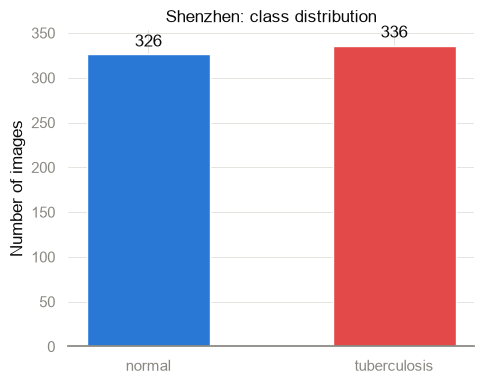

label
normal          326
tuberculosis    336
Name: count, dtype: int64
Balance ratio: 1.03x


In [4]:
counts = df["label"].value_counts().reindex(["normal", "tuberculosis"])

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.index, counts.values, color=[PALETTE["blue"], PALETTE["red"]], width=0.5)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 5, f"{v}", ha="center", va="bottom", color=INK)
ax.set_ylabel("Number of images")
ax.set_title("Shenzhen: class distribution")
ax.spines["left"].set_visible(False)
plt.tight_layout()
plt.show()
print(counts)
print(f"Balance ratio: {counts.max()/counts.min():.2f}x")

## 3. Patient-level check

Each Shenzhen filename encodes one unique numeric ID — worth confirming this is
truly one-image-per-patient (unlike Kermany, where some patients contribute
several images) before assuming a simple split is safe.

In [5]:
dupe_patients = df["patient_id"].value_counts()
print(f"Unique patient IDs: {df['patient_id'].nunique()}  |  Total images: {len(df)}")
print(f"Patients with >1 image: {(dupe_patients > 1).sum()}")
if (dupe_patients > 1).sum() == 0:
    print("--> Confirmed: Shenzhen is one image per patient. Patient-level and")
    print("    image-level splitting are equivalent here (but we still split by")
    print("    patient_id for consistency with the rest of the pipeline).")

Unique patient IDs: 662  |  Total images: 662
Patients with >1 image: 0
--> Confirmed: Shenzhen is one image per patient. Patient-level and
    image-level splitting are equivalent here (but we still split by
    patient_id for consistency with the rest of the pipeline).


## 4. Image dimensions & aspect ratio

Shenzhen images tend to be large, high-resolution PNGs from a PACS export —
different acquisition equipment than Kermany, which is one of several domain
differences (alongside patient age) that make a 4-class model's TB-vs-pneumonia
boundary partly a "which hospital/scanner" boundary rather than pure pathology.

In [6]:
sizes = []
for p in df["filepath"]:
    with Image.open(p) as im:
        sizes.append(im.size)
df["width"] = [s[0] for s in sizes]
df["height"] = [s[1] for s in sizes]
df["aspect_ratio"] = df["width"] / df["height"]
print(df[["width", "height", "aspect_ratio"]].describe())

             width       height  aspect_ratio
count   662.000000   662.000000    662.000000
mean   2699.084592  2794.069486      0.967325
std     333.911267   300.972978      0.069856
min    1130.000000   948.000000      0.759674
25%    2491.500000  2700.250000      0.916784
50%    2744.000000  2937.000000      0.997662
75%    3000.000000  2955.000000      1.017322
max    3001.000000  3001.000000      1.297064


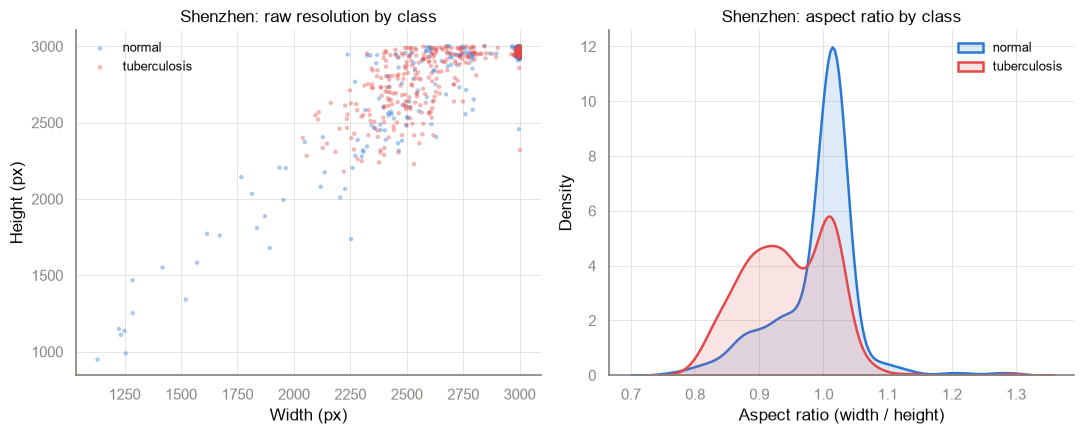

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for lbl, color in zip(["normal", "tuberculosis"], [PALETTE["blue"], PALETTE["red"]]):
    subset = df[df["label"] == lbl]
    axes[0].scatter(subset["width"], subset["height"], s=10, alpha=0.4, color=color, label=lbl, edgecolors="none")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].set_title("Shenzhen: raw resolution by class")
axes[0].legend(frameon=False, fontsize=9)

for lbl, color in zip(["normal", "tuberculosis"], [PALETTE["blue"], PALETTE["red"]]):
    subset = df[df["label"] == lbl]
    sns.kdeplot(subset["aspect_ratio"], ax=axes[1], color=color, label=lbl, fill=True, alpha=0.15, linewidth=1.8)
axes[1].set_xlabel("Aspect ratio (width / height)")
axes[1].set_title("Shenzhen: aspect ratio by class")
axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## 5. Pixel intensity distributions

Checking whether TB and normal images differ in overall brightness/contrast on
average — a systematic difference here (independent of the actual lesion) could
signal an exposure-setting shortcut rather than genuine pathology signal.

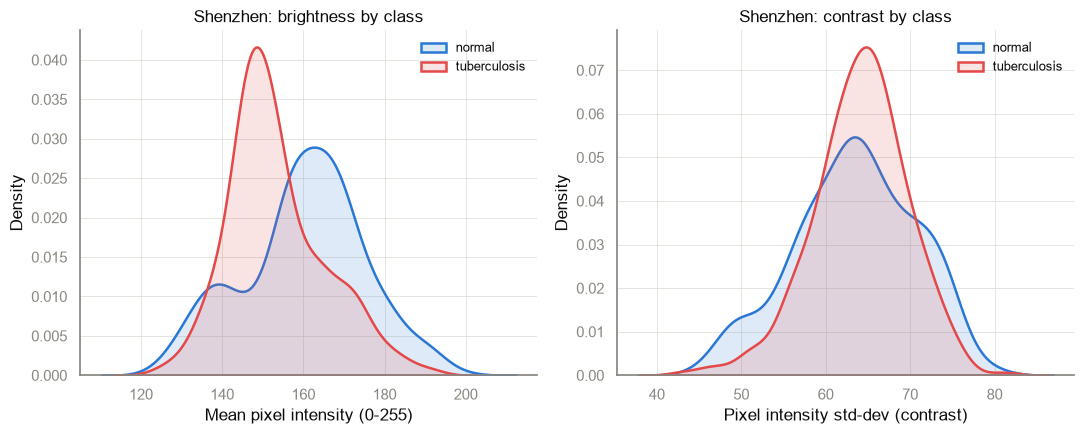

In [8]:
def grayscale_stats(paths):
    means, stds = [], []
    for p in paths:
        arr = np.array(Image.open(p).convert("L"), dtype=np.float32)
        means.append(arr.mean())
        stds.append(arr.std())
    return np.array(means), np.array(stds)

stats_by_label = {lbl: grayscale_stats(df[df["label"] == lbl]["filepath"]) for lbl in ["normal", "tuberculosis"]}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for lbl, color in zip(["normal", "tuberculosis"], [PALETTE["blue"], PALETTE["red"]]):
    means, _ = stats_by_label[lbl]
    sns.kdeplot(means, ax=axes[0], color=color, label=lbl, fill=True, alpha=0.15, linewidth=1.8)
axes[0].set_xlabel("Mean pixel intensity (0-255)")
axes[0].set_title("Shenzhen: brightness by class")
axes[0].legend(frameon=False, fontsize=9)

for lbl, color in zip(["normal", "tuberculosis"], [PALETTE["blue"], PALETTE["red"]]):
    _, stds = stats_by_label[lbl]
    sns.kdeplot(stds, ax=axes[1], color=color, label=lbl, fill=True, alpha=0.15, linewidth=1.8)
axes[1].set_xlabel("Pixel intensity std-dev (contrast)")
axes[1].set_title("Shenzhen: contrast by class")
axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## 6. Sample images per class

TB X-rays classically show upper-lobe infiltrates, cavitation, or fibrotic
changes; normal adult films show clear lung fields with visible rib/mediastinal
structures typical of an adult chest (vs. the smaller pediatric films in Kermany).

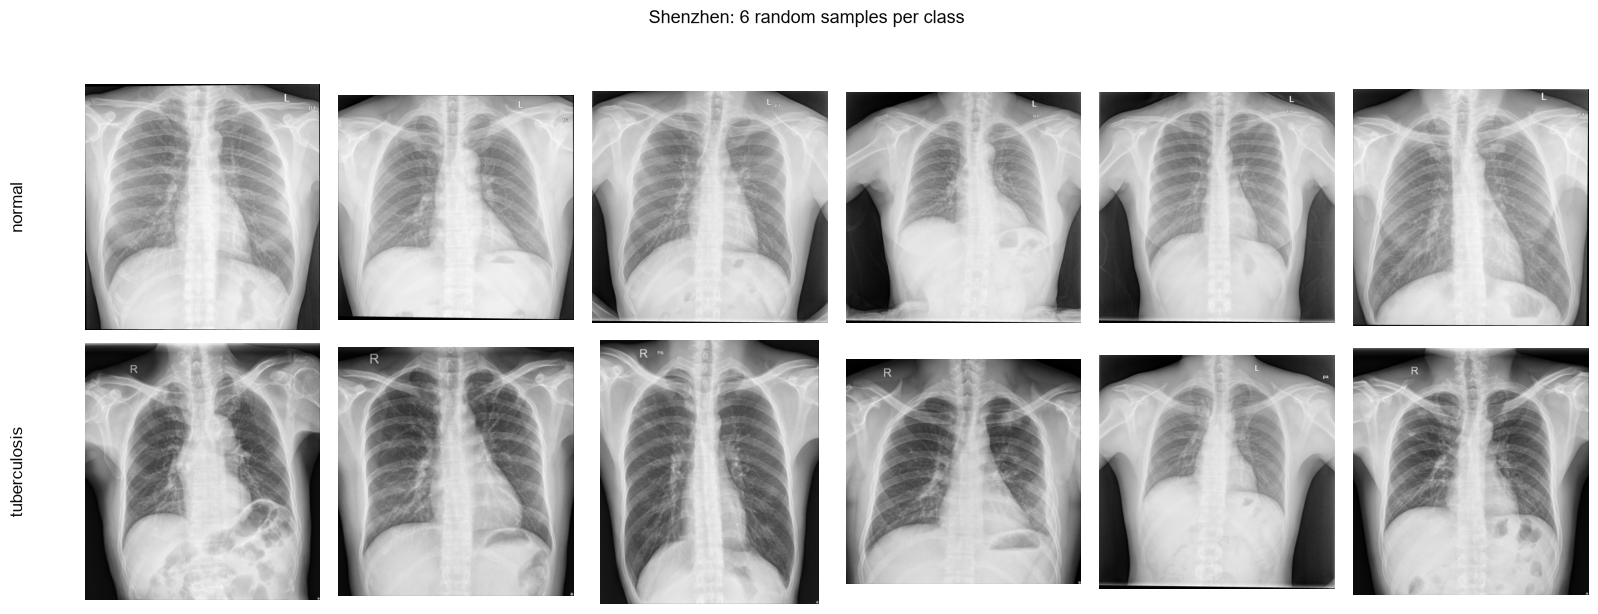

In [9]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for row, lbl in enumerate(["normal", "tuberculosis"]):
    sample_paths = df[df["label"] == lbl]["filepath"].sample(n=6, random_state=RNG_SEED).tolist()
    for col, p in enumerate(sample_paths):
        img = load_rgb(p, max_side=400)
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
    axes[row, 0].text(-0.25, 0.5, lbl, transform=axes[row, 0].transAxes,
                       ha="right", va="center", fontsize=12, color=INK, rotation=90)
fig.suptitle("Shenzhen: 6 random samples per class", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Summary — what we learned & how this dataset is used

**Findings:**
- 662 images, fairly balanced (326 normal / 336 TB) — a good training source
  precisely because the class balance is close to 1:1, unlike Montgomery.
- One image per patient — no patient-level leakage risk within this source
  (still split by `patient_id` for pipeline consistency).
- Larger, higher-resolution PACS-style images than Kermany; adult anatomy
  (larger rib cage / mediastinum) is visually distinct from Kermany's pediatric
  films — a real domain gap, not just a labeling artifact.

**How this dataset is used downstream:**
1. Provides **train + validation** examples for the `Tuberculosis` class in the
   4-class configuration only (not used in the 3-class Kermany-only benchmark).
2. Deliberately **not** used for the TB external test — that role belongs
   entirely to Montgomery (notebook 3), so we get an honest read on
   generalization to a hospital/scanner the model never trained on.
3. The domain differences documented here (adult vs. pediatric anatomy, PACS
   resolution/contrast) are the empirical basis for the domain-confound
   limitation the paper must discuss (`CLAUDE.md` §4.3, §12).